In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/ml_dataset/historical_proposals.csv")
print(df.shape)
df.head()

(800, 6)


,research_area,requested_amount_lakhs,duration_months,institution_type,num_objectives,approved
0,Environmental Rehabilitation,45.1,24,academic,2,0
1,Environmental Rehabilitation,92.2,12,cil_psu,6,1
2,Mine Waste Utilization,176.5,36,academic,3,1
3,Automation in Mining,36.7,48,academic,2,1
4,Coal Bed Methane,61.2,42,industry,5,1


In [2]:
df.describe(include="all")

,research_area,requested_amount_lakhs,duration_months,institution_type,num_objectives,approved
count,800,800.000000,800.000000,800,800.00000,800.000000
unique,8,NaN,NaN,3,NaN,NaN
top,Automation in Mining,NaN,NaN,academic,NaN,NaN
freq,124,NaN,NaN,412,NaN,NaN
mean,NaN,175.026375,31.297500,NaN,4.50875,0.565000
std,NaN,112.938445,11.954084,NaN,1.70765,0.496067
min,NaN,20.100000,12.000000,NaN,2.00000,0.000000
25%,NaN,94.375000,18.000000,NaN,3.00000,0.000000
50%,NaN,153.000000,30.000000,NaN,5.00000,1.000000
75%,NaN,233.325000,42.000000,NaN,6.00000,1.000000


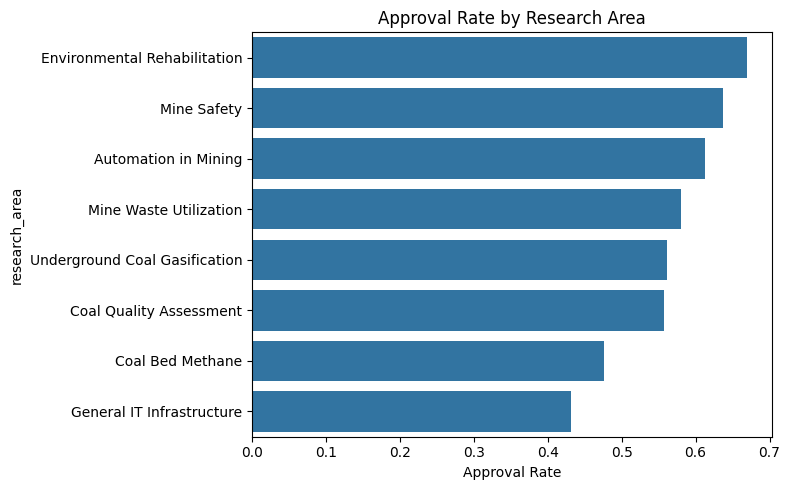

In [3]:
approval_by_area = df.groupby("research_area")["approved"].mean().sort_values(ascending=False)
plt.figure(figsize=(8,5))
sns.barplot(x=approval_by_area.values, y=approval_by_area.index)
plt.xlabel("Approval Rate")
plt.title("Approval Rate by Research Area")
plt.tight_layout()
plt.show()

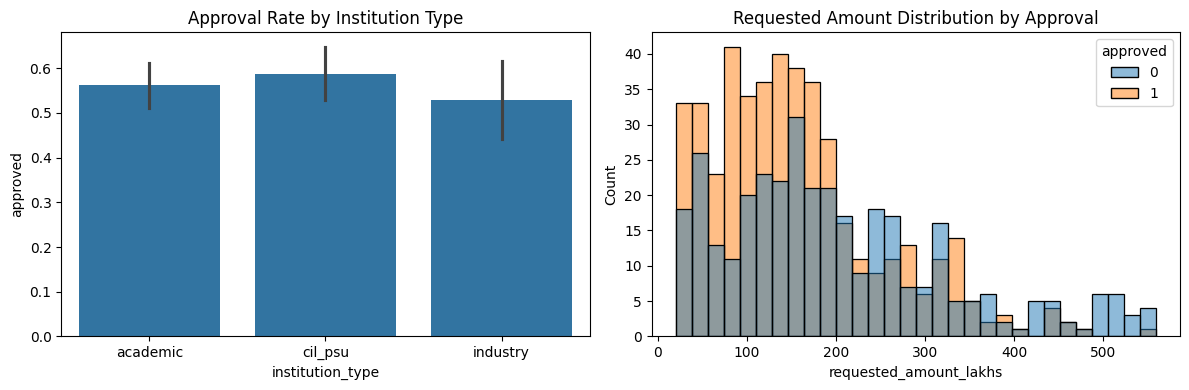

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))

sns.barplot(x="institution_type", y="approved", data=df, ax=axes[0])
axes[0].set_title("Approval Rate by Institution Type")

sns.histplot(data=df, x="requested_amount_lakhs", hue="approved", bins=30, ax=axes[1])
axes[1].set_title("Requested Amount Distribution by Approval")

plt.tight_layout()
plt.show()

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

CATEGORICAL_FEATURES = ["research_area", "institution_type"]
NUMERIC_FEATURES = ["requested_amount_lakhs", "duration_months", "num_objectives"]
TARGET = "approved"

X = df[CATEGORICAL_FEATURES + NUMERIC_FEATURES]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL_FEATURES),
    ],
    remainder="passthrough"
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (640, 5), Test: (160, 5)


In [7]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42))
])

rf_pipeline.fit(X_train, y_train)
rf_pred = rf_pipeline.predict(X_test)
rf_proba = rf_pipeline.predict_proba(X_test)[:, 1]

print(classification_report(y_test, rf_pred))
print(f"ROC-AUC: {roc_auc_score(y_test, rf_proba):.3f}")

              precision    recall  f1-score   support

           0       0.51      0.29      0.37        70
           1       0.59      0.79      0.67        90

    accuracy                           0.57       160
   macro avg       0.55      0.54      0.52       160
weighted avg       0.55      0.57      0.54       160

ROC-AUC: 0.566


In [8]:
from xgboost import XGBClassifier

xgb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(
        n_estimators=150, max_depth=4, learning_rate=0.1,
        random_state=42, eval_metric="logloss"
    ))
])

xgb_pipeline.fit(X_train, y_train)
xgb_pred = xgb_pipeline.predict(X_test)
xgb_proba = xgb_pipeline.predict_proba(X_test)[:, 1]

print(classification_report(y_test, xgb_pred))
print(f"ROC-AUC: {roc_auc_score(y_test, xgb_proba):.3f}")

              precision    recall  f1-score   support

           0       0.52      0.46      0.49        70
           1       0.62      0.68      0.65        90

    accuracy                           0.58       160
   macro avg       0.57      0.57      0.57       160
weighted avg       0.58      0.58      0.58       160

ROC-AUC: 0.610


In [9]:
from sklearn.model_selection import cross_val_score

rf_cv = cross_val_score(rf_pipeline, X, y, cv=5, scoring="roc_auc")
xgb_cv = cross_val_score(xgb_pipeline, X, y, cv=5, scoring="roc_auc")

print(f"Random Forest CV ROC-AUC: {rf_cv.mean():.3f} (+/- {rf_cv.std():.3f})")
print(f"XGBoost CV ROC-AUC:       {xgb_cv.mean():.3f} (+/- {xgb_cv.std():.3f})")

Random Forest CV ROC-AUC: 0.647 (+/- 0.026)
XGBoost CV ROC-AUC:       0.637 (+/- 0.032)


In [10]:
print("Class balance:", y.value_counts(normalize=True).to_dict())
print("\nFeature correlations with target (numeric only):")
print(df[NUMERIC_FEATURES + [TARGET]].corr()["approved"])

print("\nApproval rate by research_area:")
print(df.groupby("research_area")["approved"].mean().sort_values(ascending=False))

print("\nApproval rate by institution_type:")
print(df.groupby("institution_type")["approved"].mean().sort_values(ascending=False))

Class balance: {1: 0.565, 0: 0.435}

Feature correlations with target (numeric only):
requested_amount_lakhs   -0.196196
duration_months          -0.076923
num_objectives           -0.073806
approved                  1.000000
Name: approved, dtype: float64

Approval rate by research_area:
research_area
Environmental Rehabilitation     0.669811
Mine Safety                      0.637500
Automation in Mining             0.612903
Mine Waste Utilization           0.580247
Underground Coal Gasification    0.560748
Coal Quality Assessment          0.556701
Coal Bed Methane                 0.475728
General IT Infrastructure        0.431373
Name: approved, dtype: float64

Approval rate by institution_type:
institution_type
cil_psu     0.588000
academic    0.563107
industry    0.528986
Name: approved, dtype: float64


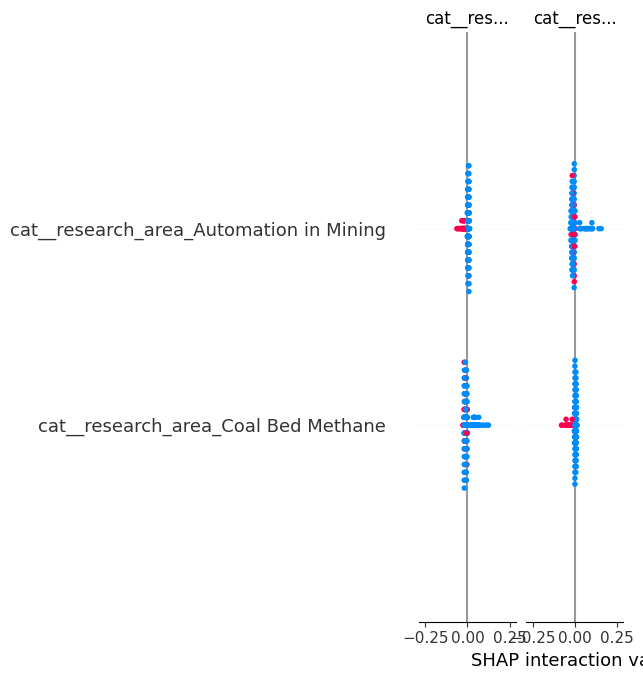

In [12]:
import shap

X_test_transformed = rf_pipeline.named_steps["preprocessor"].transform(X_test)
feature_names = rf_pipeline.named_steps["preprocessor"].get_feature_names_out()

explainer = shap.TreeExplainer(rf_pipeline.named_steps["classifier"])
shap_values = explainer.shap_values(X_test_transformed)

# For binary classification, shap_values may be a list [class0, class1] or a single array
if isinstance(shap_values, list):
    shap_values_to_plot = shap_values[1]
else:
    shap_values_to_plot = shap_values

import pandas as pd
X_test_df = pd.DataFrame(X_test_transformed, columns=feature_names)

shap.summary_plot(shap_values_to_plot, X_test_df, show=True)

In [13]:
import numpy as np
print("shap_values type:", type(shap_values))
if isinstance(shap_values, list):
    print("list length:", len(shap_values), "each shape:", shap_values[0].shape)
else:
    print("shape:", shap_values.shape)
print("feature_names length:", len(feature_names))

shap_values type: <class 'numpy.ndarray'>
shape: (160, 14, 2)
feature_names length: 14


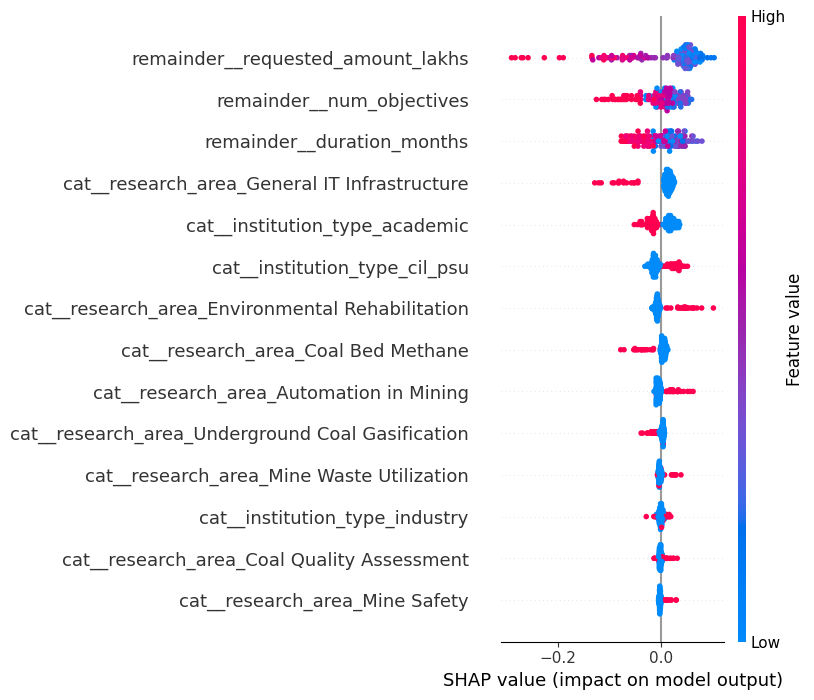

In [14]:
import shap
import pandas as pd

X_test_transformed = rf_pipeline.named_steps["preprocessor"].transform(X_test)
feature_names = rf_pipeline.named_steps["preprocessor"].get_feature_names_out()

explainer = shap.TreeExplainer(rf_pipeline.named_steps["classifier"])
shap_values = explainer.shap_values(X_test_transformed)

# shap_values shape: (n_samples, n_features, n_classes) -> take class 1 
shap_values_to_plot = shap_values[:, :, 1]

X_test_df = pd.DataFrame(X_test_transformed, columns=feature_names)

shap.summary_plot(shap_values_to_plot, X_test_df, show=True)

In [15]:
import joblib
import os

model_dir = "../data/ml_dataset"
os.makedirs(model_dir, exist_ok=True)

model_path = os.path.join(model_dir, "approval_model.joblib")
joblib.dump(rf_pipeline, model_path)

print(f"Model saved to {model_path}")
print(f"Feature columns expected: {CATEGORICAL_FEATURES + NUMERIC_FEATURES}")

Model saved to ../data/ml_dataset\approval_model.joblib
Feature columns expected: ['research_area', 'institution_type', 'requested_amount_lakhs', 'duration_months', 'num_objectives']
